# Static Feature Audit

Use this notebook to verify terrain / soil static maps before plugging them into the stage-2 static-aware GPT experiments.


In [1]:
import sys
from pathlib import Path


def find_gptcast_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / 'gptcast').is_dir():
            return p
        if (p / 'GPTCast' / 'gptcast').is_dir():
            return (p / 'GPTCast').resolve()
        p = p.parent
    return start.resolve()


ROOT = find_gptcast_root(Path.cwd())
NOTEBOOK_DIR = ROOT / 'notebooks' / 'rzsm'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

print('Using ROOT:', ROOT)

from static_feature_audit import DEFAULT_STATIC_KEYS, load_static_maps, plot_static_maps


Using ROOT: /home/ang/GPTCast


## Configuration


In [2]:
static_dir = ROOT / 'data' / '0.1' / '1' / 'static'
selected_keys = [
    'land_mask',
    'elevation_m',
    'slope_degrees',
    'aspect_sin',
    'aspect_cos',
    'sand_fraction',
    'clay_fraction',
    'silt_fraction',
    'porosity',
    'field_capacity',
    'wilting_point',
    'depth_to_bedrock_m',
    'depth_to_water_table_m',
    'topographic_wetness_index',
]

print('Static dir:', static_dir)
print('Requested keys:', selected_keys)


Static dir: /home/ang/GPTCast/data/0.1/1/static
Requested keys: ['land_mask', 'elevation_m', 'slope_degrees', 'aspect_sin', 'aspect_cos', 'sand_fraction', 'clay_fraction', 'silt_fraction', 'porosity', 'field_capacity', 'wilting_point', 'depth_to_bedrock_m', 'depth_to_water_table_m', 'topographic_wetness_index']


## Available static maps


In [3]:
maps = load_static_maps(static_dir, keys=selected_keys)
print('Available keys on disk:')
for key, da in maps.items():
    print(f'  - {key}: shape={tuple(da.shape)}, min={float(da.min(skipna=True)):.4f}, max={float(da.max(skipna=True)):.4f}')


Available keys on disk:
  - land_mask: shape=(221, 201), min=0.0000, max=1.0000
  - sand_fraction: shape=(221, 201), min=-0.0000, max=0.7061
  - clay_fraction: shape=(221, 201), min=0.0000, max=0.5529
  - silt_fraction: shape=(221, 201), min=-0.0000, max=0.6431
  - porosity: shape=(221, 201), min=0.3817, max=1.0000


## Plot maps


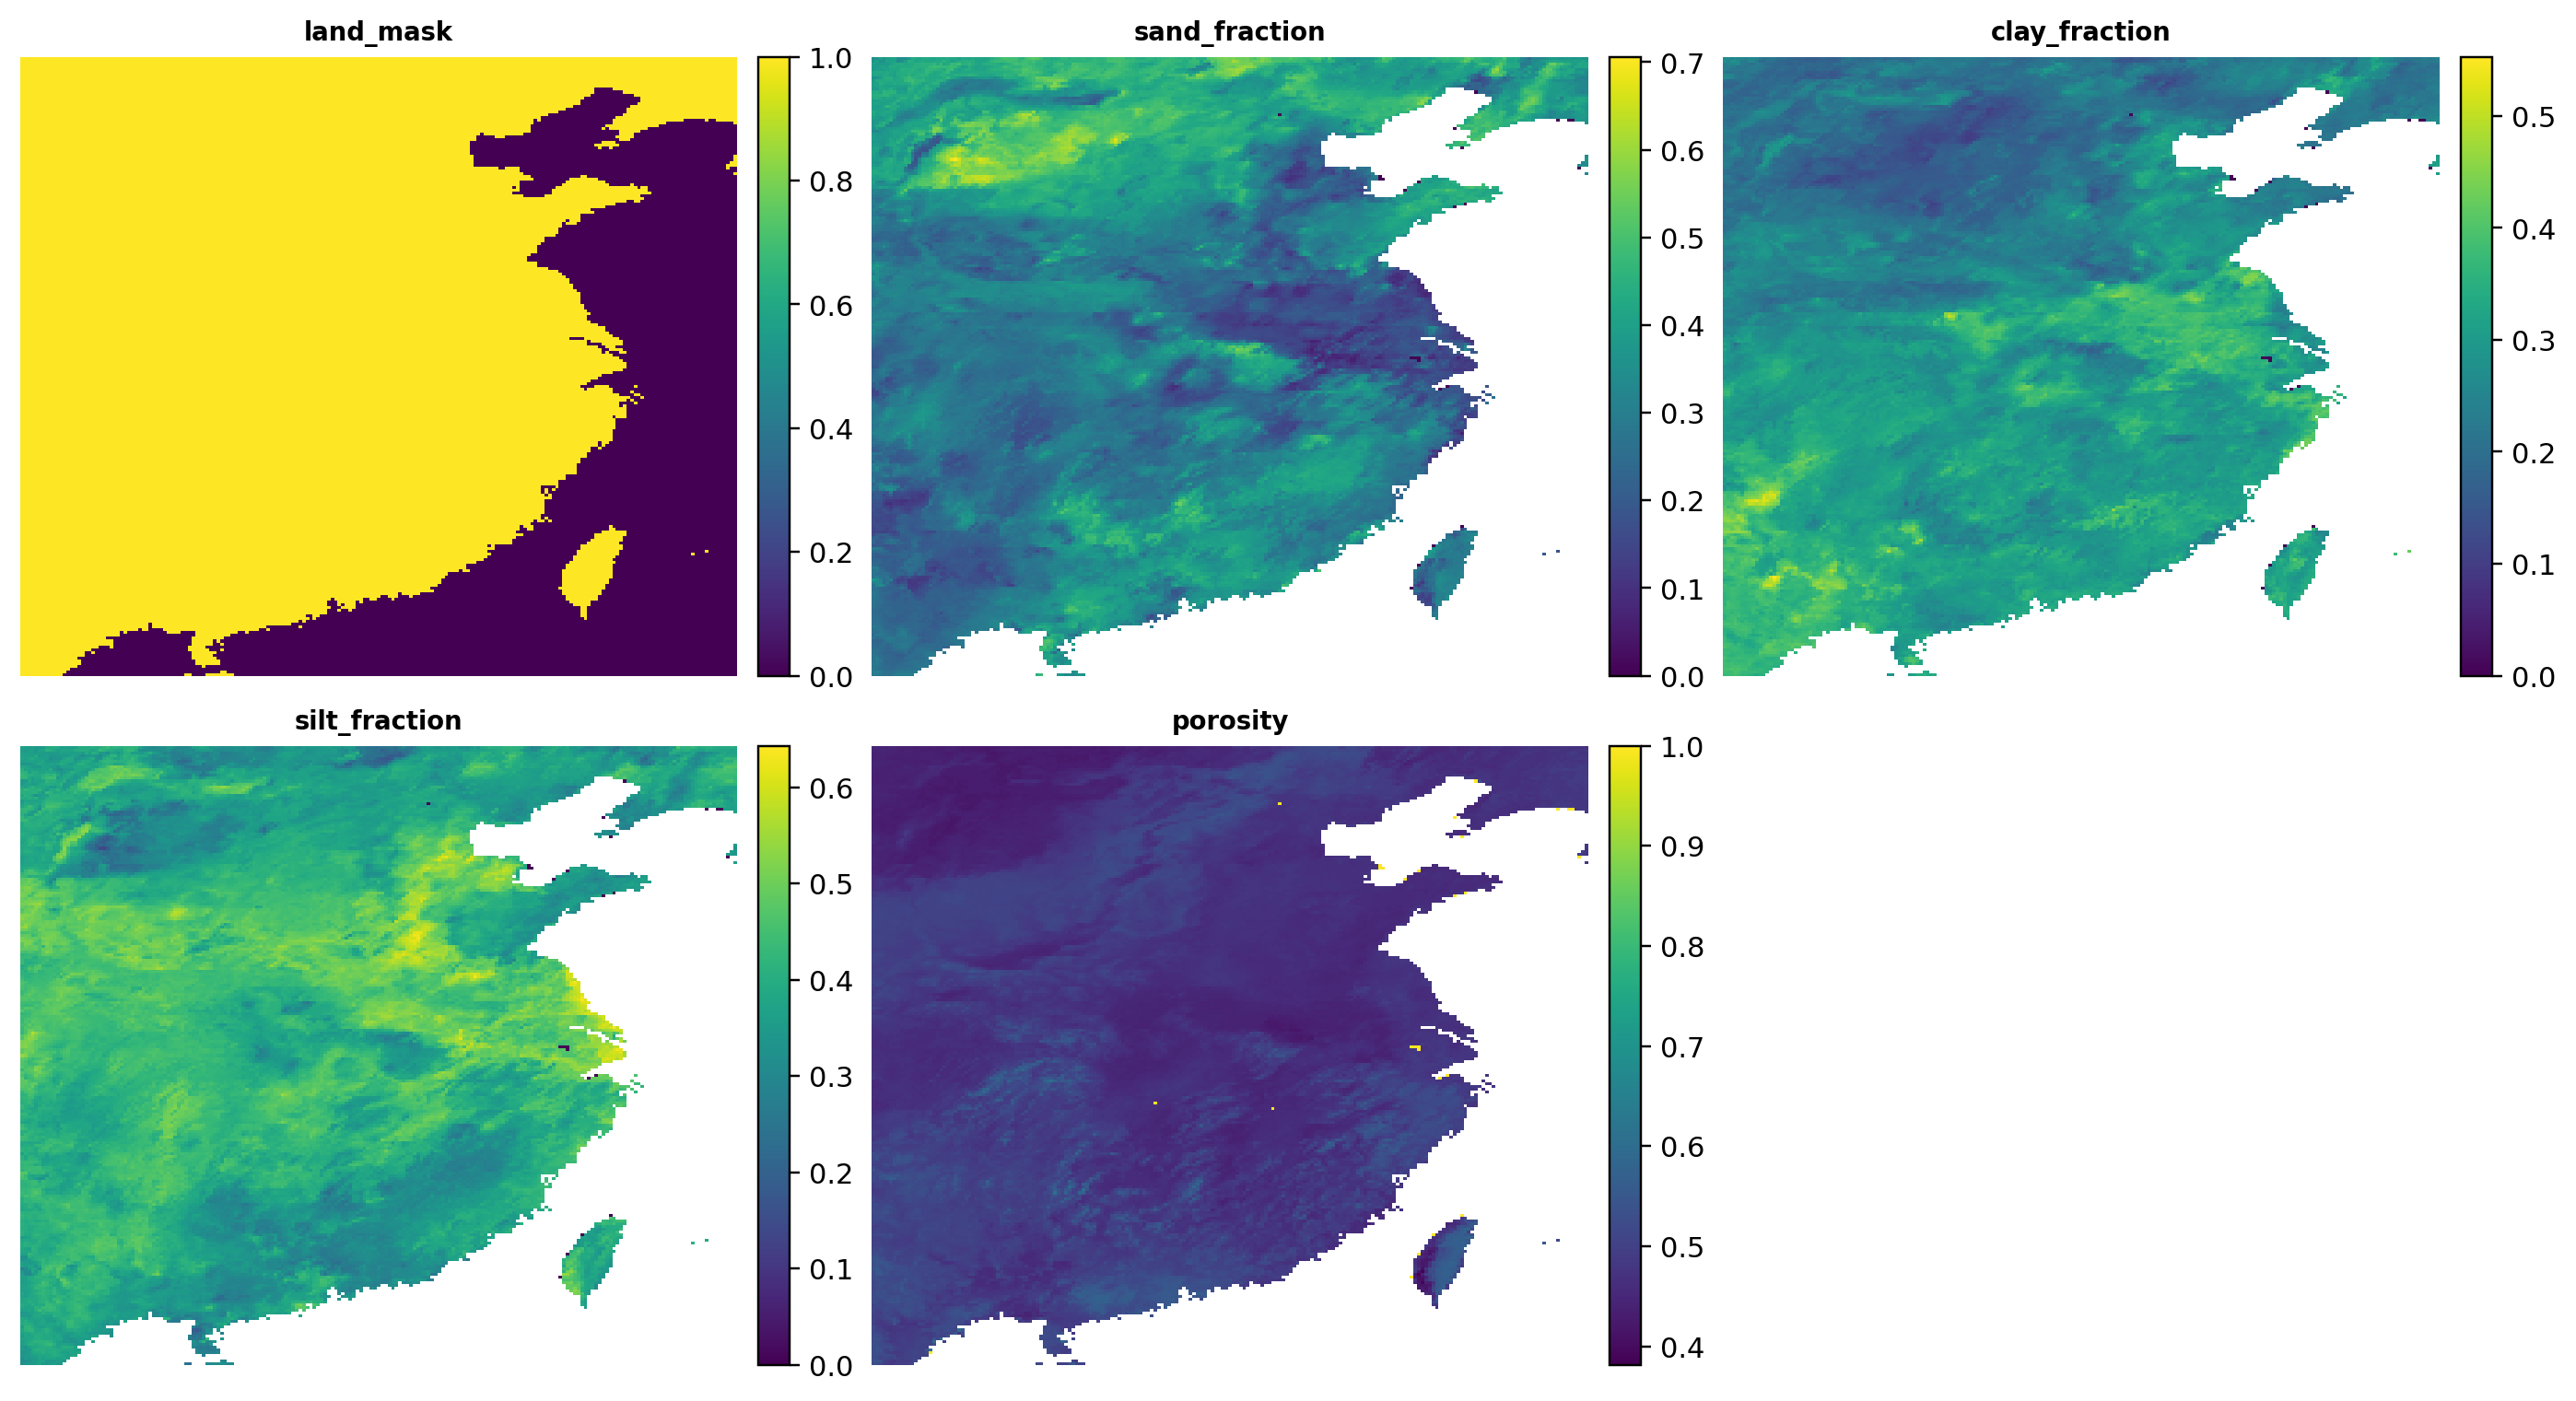

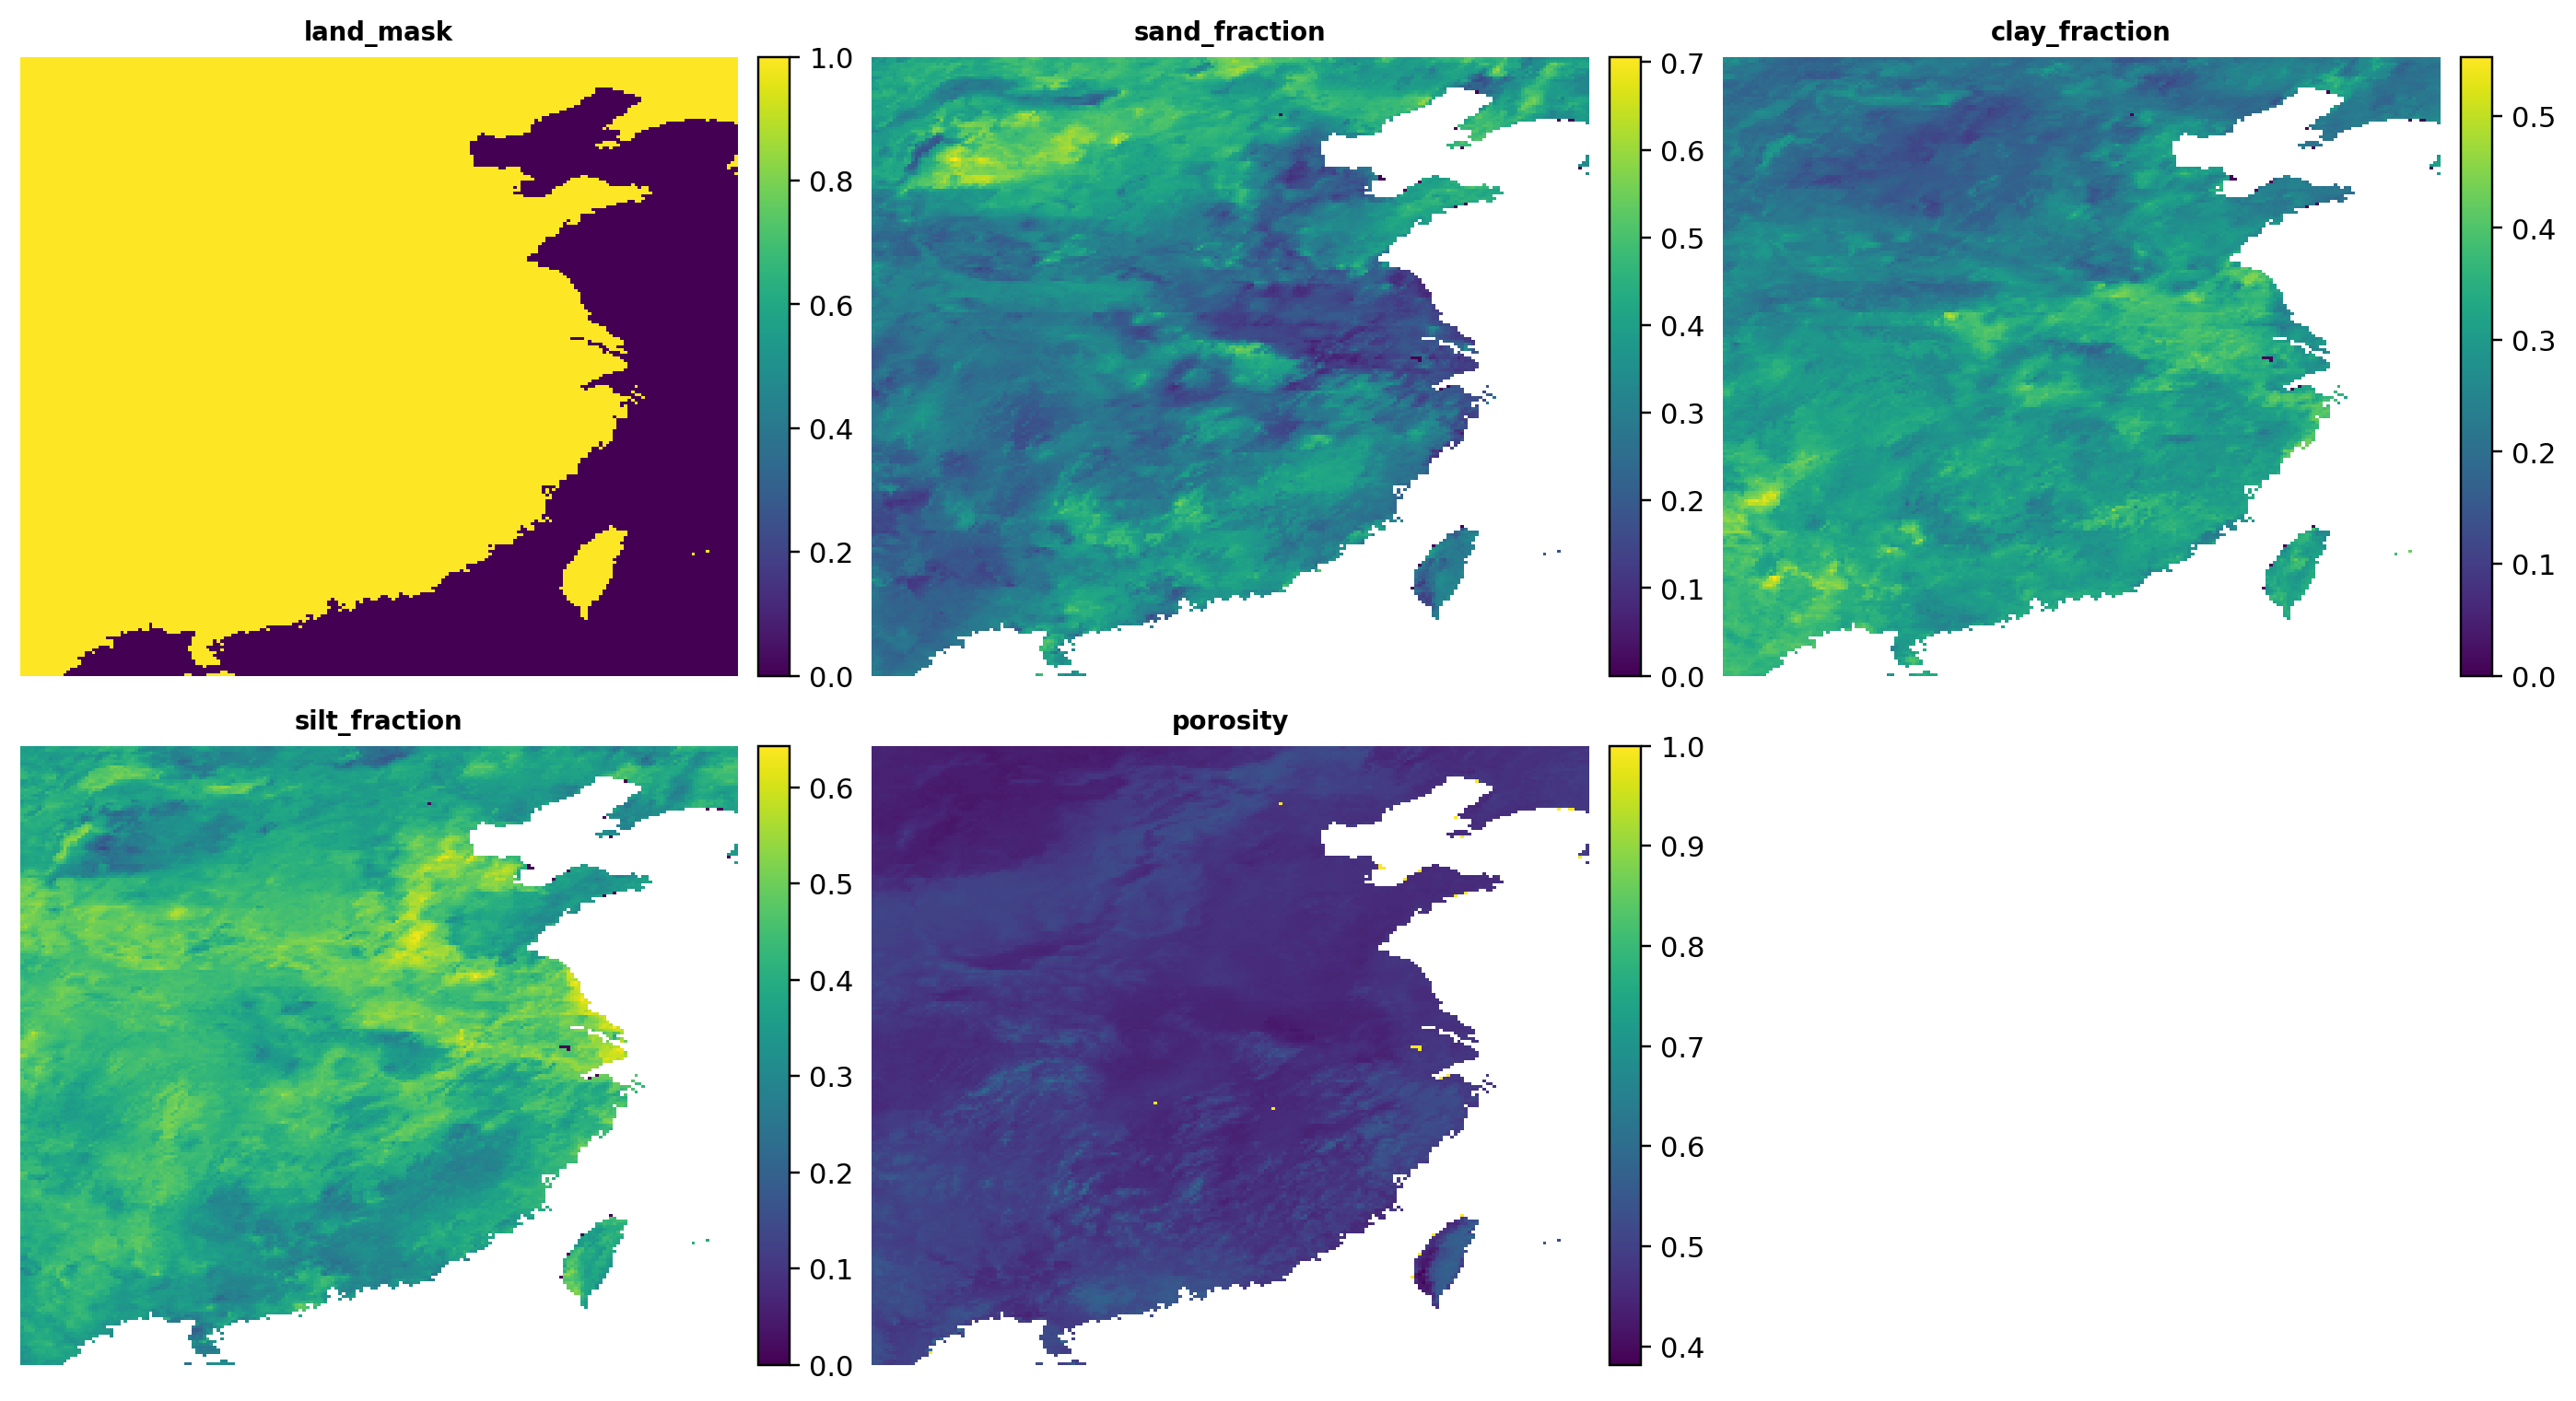

In [4]:
fig, axes = plot_static_maps(static_dir, keys=selected_keys)
fig
